# Analisa Komparasi Multi-Seed: with_geom vs no_geom
Rahmat Zulfikri · Magister Teknik Elektro UGM

**Pertanyaan riset:** Apakah penambahan fitur geometri (14 dim) ke GeoAtt-PointNet++ memberikan dampak **signifikan secara statistik** pada akurasi identifikasi telapak tangan (1:N)?

**Hipotesis:**
- H₀ (null): mean_Rank-1(with_geom) = mean_Rank-1(no_geom) — geometri tidak berpengaruh.
- H₁ (alternatif): mean_Rank-1(with_geom) > mean_Rank-1(no_geom) — geometri meningkatkan identifikasi.

**Metode statistik:**
1. **Paired t-test / Wilcoxon signed-rank** pada Rank-1 antar 5 seed (n=5 pasang).
2. **Bootstrap 95% CI** untuk delta mean Rank-1 (n_bootstrap=2000).
3. **McNemar test** pada keputusan Rank-1 per probe (apakah pola benar/salah berbeda signifikan).

**Verdict TERBUKTI** memerlukan SEMUA berikut:
- mean(with_geom) > mean(no_geom)
- p-value < 0.05 (paired test)
- 95% CI bootstrap tidak melingkupi 0

---

### Sections
1. Setup
2. Load & verifikasi test set identik (fingerprint check)
3. Headline metrik identifikasi (mean ± std antar seed)
4. Statistik inferensial (paired test + bootstrap + McNemar)
5. CMC overlay (with_geom vs no_geom)
6. Visualisasi pembanding (bar chart + signifikansi, t-SNE side-by-side)
7. Verdict + ekspor `comparison_report.md`
8. Metrik verifikasi sekunder (EER/AUC)

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install numpy matplotlib pandas scikit-learn scipy -q

import json
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

PROJECT_ROOT = Path('/content/drive/MyDrive/3DCNN')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

EVAL_DIR = PROJECT_ROOT / 'eval_results'
COMPARE_TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
COMPARE_DIR = EVAL_DIR / 'compare' / COMPARE_TIMESTAMP
COMPARE_DIR.mkdir(parents=True, exist_ok=True)

from utils.metrics import bootstrap_ci, paired_test, mcnemar_test

print(f"Project root      : {PROJECT_ROOT}")
print(f"Eval root         : {EVAL_DIR}")
print(f"Compare timestamp : {COMPARE_TIMESTAMP}")
print(f"Output            : {COMPARE_DIR}")

Mounted at /content/drive
Project root      : /content/drive/MyDrive/3DCNN
Eval root         : /content/drive/MyDrive/3DCNN/eval_results
Compare timestamp : 20260516_225103
Output            : /content/drive/MyDrive/3DCNN/eval_results/compare/20260516_225103


## 2. Load Hasil Evaluasi & Verifikasi Test Set Identik

Auto-detect timestamp evaluasi terbaru di `eval_results/with_geom/` dan `eval_results/no_geom/`,
lalu **verifikasi `test_fingerprint` identik** untuk kedua varian (paired comparison hanya valid jika test set sama).

In [2]:
def find_latest_eval_run(variant_dir: Path) -> Path | None:
    """Return latest timestamp dir under eval_results/<variant>/ that contains results.json."""
    if not variant_dir.exists():
        return None
    cands = [d for d in variant_dir.iterdir()
             if d.is_dir() and (d / 'results.json').exists()]
    if not cands:
        return None
    return max(cands, key=lambda p: p.name)


def load_eval_run(run_dir: Path) -> dict:
    """Load results.json + per-seed results_seed_*.json + embeddings_seed_*.npz."""
    with open(run_dir / 'results.json') as f:
        agg = json.load(f)

    per_seed = {}
    for seed in agg['seeds']:
        json_path = run_dir / f'results_seed_{seed}.json'
        npz_path  = run_dir / f'embeddings_seed_{seed}.npz'
        if not json_path.exists():
            print(f'  ⚠️  {json_path.name} hilang')
            continue
        with open(json_path) as f:
            rec = json.load(f)
        rec['_npz_path'] = str(npz_path)
        if npz_path.exists():
            rec['_npz'] = np.load(npz_path, allow_pickle=True)
        per_seed[seed] = rec
    return {'aggregate': agg, 'per_seed': per_seed, 'run_dir': str(run_dir)}


# ── Auto-detect run terbaru per varian ────────────────────────────────────────
with_run = find_latest_eval_run(EVAL_DIR / 'with_geom')
no_run   = find_latest_eval_run(EVAL_DIR / 'no_geom')

assert with_run is not None, (
    f"Tidak ada hasil eval di {EVAL_DIR / 'with_geom'}. Jalankan evaluate.ipynb dulu."
)
assert no_run is not None, (
    f"Tidak ada hasil eval di {EVAL_DIR / 'no_geom'}. Jalankan evaluate_no_geom.ipynb dulu."
)

print(f"with_geom run : {with_run.name}")
print(f"no_geom run   : {no_run.name}")
print()

with_data = load_eval_run(with_run)
no_data   = load_eval_run(no_run)

# ── Verifikasi test fingerprint identik ──────────────────────────────────────
fp_with = with_data['aggregate']['test_fingerprint']
fp_no   = no_data['aggregate']['test_fingerprint']

print(f"test_fingerprint with_geom : {fp_with}")
print(f"test_fingerprint no_geom   : {fp_no}")

if fp_with != fp_no:
    raise RuntimeError(
        f"❌ test_fingerprint BERBEDA antar varian — perbandingan tidak valid!\n"
        f"   with_geom: {fp_with}\n"
        f"   no_geom  : {fp_no}\n"
        f"   Penyebab umum: SPLIT_SEED berbeda, dataset_balance berbeda, atau "
        f"   train timestamp berbeda. Pastikan kedua varian dilatih+dievaluasi "
        f"   pada konfigurasi data yang sama."
    )
print("\n✅ test_fingerprint IDENTIK → perbandingan paired valid.")

# ── Cocokkan seed antar varian ───────────────────────────────────────────────
common_seeds = sorted(set(with_data['per_seed'].keys()) & set(no_data['per_seed'].keys()))
assert len(common_seeds) > 0, "Tidak ada seed yang sama antar varian."
print(f"\nSeed yang dipasangkan ({len(common_seeds)}): {common_seeds}")

with_geom run : 20260516_223830
no_geom run   : 20260516_223800

test_fingerprint with_geom : 34b90906c80ab1eb
test_fingerprint no_geom   : 34b90906c80ab1eb

✅ test_fingerprint IDENTIK → perbandingan paired valid.

Seed yang dipasangkan (5): [7, 42, 123, 2026, 31337]


In [3]:
# Bangun array per-seed untuk metrik utama (paired)
def metric_array(data: dict, key: str, seeds: list[int]) -> np.ndarray:
    return np.array([data['per_seed'][s][key] for s in seeds], dtype=np.float64)

PRIMARY_KEYS   = ['rank1', 'rank5', 'rank10', 'map']
SECONDARY_KEYS = ['eer', 'auc', 'tar_at_far1', 'tar_at_far01', 'dprime']

paired_arrays = {}
for key in PRIMARY_KEYS + SECONDARY_KEYS:
    paired_arrays[key] = {
        'with_geom': metric_array(with_data, key, common_seeds),
        'no_geom':   metric_array(no_data,   key, common_seeds),
    }

# Sanity print
print("Array per-seed siap.")
for key in ['rank1', 'eer']:
    a = paired_arrays[key]['with_geom']
    b = paired_arrays[key]['no_geom']
    print(f"  {key:<8} with_geom={[f'{v:.3f}' for v in a]}  mean={a.mean():.4f}")
    print(f"  {key:<8} no_geom  ={[f'{v:.3f}' for v in b]}  mean={b.mean():.4f}")

Array per-seed siap.
  rank1    with_geom=['0.973', '0.964', '0.964', '0.964', '0.927']  mean=0.9582
  rank1    no_geom  =['1.000', '1.000', '1.000', '1.000', '0.991']  mean=0.9982
  eer      with_geom=['0.019', '0.017', '0.018', '0.030', '0.054']  mean=0.0276
  eer      no_geom  =['0.000', '0.001', '0.000', '0.000', '0.001']  mean=0.0003


## 3. Headline Metrik Identifikasi (Mean ± Std antar Seed)

Tabel utama untuk klaim tesis. Fokus pada Rank-1, Rank-5, Rank-10, mAP.

In [4]:
def headline_table(arrays: dict, keys: list[str], lower_better_keys: set[str]) -> pd.DataFrame:
    rows = []
    for key in keys:
        a = arrays[key]['with_geom']
        b = arrays[key]['no_geom']
        delta = a.mean() - b.mean()
        # Improvement positif jika geom lebih baik
        if key in lower_better_keys:
            better = delta < 0
            pct = -delta / b.mean() * 100 if b.mean() != 0 else 0
        else:
            better = delta > 0
            pct = delta / b.mean() * 100 if b.mean() != 0 else 0
        rows.append({
            'Metrik':    key,
            'with_geom_mean': a.mean(),
            'with_geom_std':  a.std(),
            'no_geom_mean':   b.mean(),
            'no_geom_std':    b.std(),
            'delta':          delta,
            'improvement_%':  pct,
            'geom_better':    '✓' if better else '✗',
        })
    return pd.DataFrame(rows)


print("=" * 72)
print(f"HEADLINE — IDENTIFIKASI 1:N  ({len(common_seeds)} seed paired)")
print("=" * 72)
df_primary = headline_table(paired_arrays, PRIMARY_KEYS, lower_better_keys=set())
print(df_primary.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

print()
print("=" * 72)
print(f"VERIFIKASI 1:1 (sekunder)")
print("=" * 72)
df_secondary = headline_table(paired_arrays, SECONDARY_KEYS, lower_better_keys={'eer'})
print(df_secondary.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

HEADLINE — IDENTIFIKASI 1:N  (5 seed paired)
Metrik  with_geom_mean  with_geom_std  no_geom_mean  no_geom_std   delta  improvement_% geom_better
 rank1          0.9582         0.0159        0.9982       0.0036 -0.0400        -4.0073           ✗
 rank5          0.9964         0.0073        1.0000       0.0000 -0.0036        -0.3636           ✗
rank10          1.0000         0.0000        1.0000       0.0000  0.0000         0.0000           ✗
   map          0.9729         0.0108        0.9988       0.0024 -0.0258        -2.5880           ✗

VERIFIKASI 1:1 (sekunder)
      Metrik  with_geom_mean  with_geom_std  no_geom_mean  no_geom_std   delta  improvement_% geom_better
         eer          0.0276         0.0141        0.0003       0.0004  0.0272     -8057.1429           ✗
         auc          0.9962         0.0026        1.0000       0.0000 -0.0038        -0.3841           ✗
 tar_at_far1          0.9287         0.0134        1.0000       0.0000 -0.0713        -7.1270           ✗
tar_

## 4. Statistik Inferensial — Paired Test, Bootstrap CI, McNemar

- **Paired t-test** (atau Wilcoxon jika n<10) pada Rank-1 antar seed.
- **Bootstrap 95% CI** untuk delta mean Rank-1 (n_bootstrap=2000, paired).
- **McNemar test** pada keputusan Rank-1 per probe (gabungan semua seed).

In [5]:
stats_results = {}

print("=" * 72)
print("STATISTIK INFERENSIAL — IDENTIFIKASI 1:N")
print("=" * 72)

for key in PRIMARY_KEYS:
    a = paired_arrays[key]['with_geom']
    b = paired_arrays[key]['no_geom']

    # Paired test (auto: wilcoxon untuk n<10)
    paired = paired_test(a, b, test='auto')
    # Bootstrap 95% CI untuk delta = mean(a) - mean(b)
    boot = bootstrap_ci(a, b, n_bootstrap=2000, paired=True, confidence=0.95)

    stats_results[key] = {'paired': paired, 'bootstrap': boot}

    sig = '*' if paired['pvalue'] < 0.05 else ''
    sig += '*' if paired['pvalue'] < 0.01 else ''
    sig += '*' if paired['pvalue'] < 0.001 else ''
    ci_excludes_zero = (boot['ci_low'] > 0) or (boot['ci_high'] < 0)

    print(f"\n[{key.upper()}]")
    print(f"  with_geom : mean={a.mean():.4f}  std={a.std():.4f}")
    print(f"  no_geom   : mean={b.mean():.4f}  std={b.std():.4f}")
    print(f"  delta     : {boot['mean']:+.4f}  (with_geom − no_geom)")
    print(f"  Paired {paired['test']:<9} : statistic={paired['statistic']:.4f}  p={paired['pvalue']:.4f}  {sig}")
    print(f"  Bootstrap CI 95% : [{boot['ci_low']:+.4f}, {boot['ci_high']:+.4f}]  "
          f"{'(excludes 0)' if ci_excludes_zero else '(includes 0 — tidak signifikan)'}")


# ── McNemar pada keputusan Rank-1 per probe (digabung antar seed) ──────────
print()
print("=" * 72)
print("MCNEMAR TEST — keputusan Rank-1 per probe (digabungkan seluruh seed)")
print("=" * 72)

correct_with = []
correct_no   = []
for s in common_seeds:
    npz_w = with_data['per_seed'][s].get('_npz')
    npz_n = no_data['per_seed'][s].get('_npz')
    if npz_w is None or npz_n is None:
        print(f"  ⚠️  embeddings_seed_{s}.npz hilang — skip seed ini")
        continue
    cw = npz_w['correct_rank1']
    cn = npz_n['correct_rank1']
    assert len(cw) == len(cn), f"jumlah probe berbeda di seed {s}"
    correct_with.append(cw)
    correct_no.append(cn)

if correct_with:
    correct_with = np.concatenate(correct_with)
    correct_no   = np.concatenate(correct_no)
    mcn = mcnemar_test(correct_with, correct_no, continuity_correction=True)
    stats_results['mcnemar_rank1'] = mcn

    n_total = mcn['n']
    print(f"  Total probe (gabung seed) : {n_total}")
    print(f"  with_geom benar saja      : {mcn['c']}  (b dalam tabel)")
    print(f"  no_geom   benar saja      : {mcn['b']}  (c dalam tabel)")
    print(f"  Statistic χ²              : {mcn['statistic']:.4f}")
    print(f"  p-value                   : {mcn['pvalue']:.4f}")
    if mcn['pvalue'] < 0.05:
        print(f"  → Signifikan: pola benar/salah berbeda antar varian")
    else:
        print(f"  → Tidak signifikan: pola benar/salah konsisten antar varian")
else:
    print("  Tidak ada embedding npz tersedia — McNemar dilewati.")
    stats_results['mcnemar_rank1'] = None

STATISTIK INFERENSIAL — IDENTIFIKASI 1:N

[RANK1]
  with_geom : mean=0.9582  std=0.0159
  no_geom   : mean=0.9982  std=0.0036
  delta     : -0.0400  (with_geom − no_geom)
  Paired wilcoxon  : statistic=0.0000  p=0.0625  
  Bootstrap CI 95% : [-0.0527, -0.0309]  (excludes 0)

[RANK5]
  with_geom : mean=0.9964  std=0.0073
  no_geom   : mean=1.0000  std=0.0000
  delta     : -0.0036  (with_geom − no_geom)
  Paired wilcoxon  : statistic=5.0000  p=1.0000  
  Bootstrap CI 95% : [-0.0109, +0.0000]  (includes 0 — tidak signifikan)

[RANK10]
  with_geom : mean=1.0000  std=0.0000
  no_geom   : mean=1.0000  std=0.0000
  delta     : +0.0000  (with_geom − no_geom)
  Paired wilcoxon  : statistic=0.0000  p=1.0000  
  Bootstrap CI 95% : [+0.0000, +0.0000]  (includes 0 — tidak signifikan)

[MAP]
  with_geom : mean=0.9729  std=0.0108
  no_geom   : mean=0.9988  std=0.0024
  delta     : -0.0258  (with_geom − no_geom)
  Paired wilcoxon  : statistic=0.0000  p=0.0625  
  Bootstrap CI 95% : [-0.0345, -0.0188] 

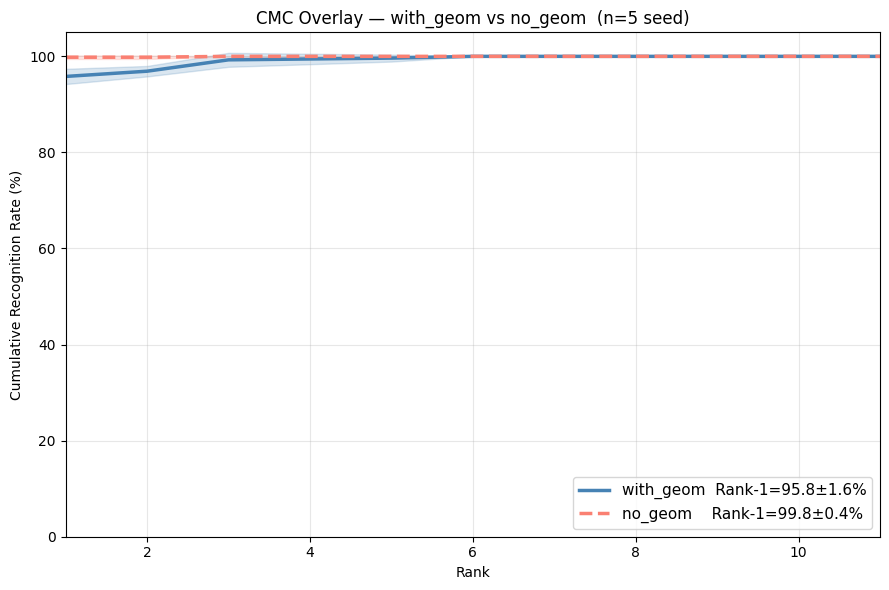

CMC overlay disimpan: /content/drive/MyDrive/3DCNN/eval_results/compare/20260516_225103/cmc_overlay.png


In [6]:
# ============================================================================
# Section 5: CMC Overlay (with_geom vs no_geom) — pita confidence per varian
# ============================================================================

def cmc_matrix(data: dict, seeds: list[int]) -> np.ndarray:
    return np.stack([np.array(data['per_seed'][s]['cmc']) for s in seeds])

cmc_w = cmc_matrix(with_data, common_seeds)  # (n_seed, max_rank)
cmc_n = cmc_matrix(no_data,   common_seeds)
mean_w, std_w = cmc_w.mean(axis=0), cmc_w.std(axis=0)
mean_n, std_n = cmc_n.mean(axis=0), cmc_n.std(axis=0)
ranks = np.arange(1, len(mean_w) + 1)

fig, ax = plt.subplots(figsize=(9, 6))
# with_geom (biru)
ax.plot(ranks, mean_w * 100, color='steelblue', lw=2.5,
        label=f'with_geom  Rank-1={mean_w[0]*100:.1f}±{std_w[0]*100:.1f}%')
ax.fill_between(ranks, (mean_w - std_w) * 100, (mean_w + std_w) * 100,
                color='steelblue', alpha=0.2)
# no_geom (oranye)
ax.plot(ranks, mean_n * 100, color='salmon', lw=2.5, linestyle='--',
        label=f'no_geom    Rank-1={mean_n[0]*100:.1f}±{std_n[0]*100:.1f}%')
ax.fill_between(ranks, (mean_n - std_n) * 100, (mean_n + std_n) * 100,
                color='salmon', alpha=0.2)

ax.set_xlabel('Rank')
ax.set_ylabel('Cumulative Recognition Rate (%)')
ax.set_title(f'CMC Overlay — with_geom vs no_geom  (n={len(common_seeds)} seed)')
ax.set_ylim(0, 105)
ax.set_xlim(1, len(mean_w))
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=11)
fig.tight_layout()
cmc_path = COMPARE_DIR / 'cmc_overlay.png'
fig.savefig(cmc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'CMC overlay disimpan: {cmc_path}')

## 6. Visualisasi Pembanding

- Bar chart Rank-N dengan error bar dan tanda signifikansi (`*` p<0.05, `**` p<0.01, `***` p<0.001).
- t-SNE side-by-side (seed pertama yang ada di kedua varian).

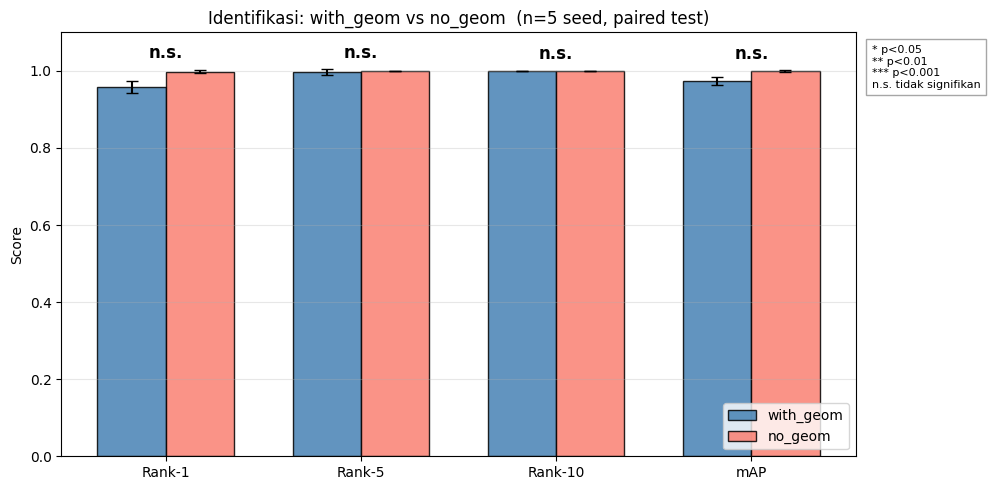

Bar chart disimpan: /content/drive/MyDrive/3DCNN/eval_results/compare/20260516_225103/bar_chart_rank.png


In [7]:
# ── Bar chart Rank-N dengan error bar + tanda signifikansi ──────────────────
def sig_marker(p: float) -> str:
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

fig, ax = plt.subplots(figsize=(10, 5))
metrics_to_plot = ['rank1', 'rank5', 'rank10', 'map']
labels_plot = ['Rank-1', 'Rank-5', 'Rank-10', 'mAP']
x = np.arange(len(metrics_to_plot))
width = 0.35

vals_w = [paired_arrays[k]['with_geom'].mean() for k in metrics_to_plot]
errs_w = [paired_arrays[k]['with_geom'].std()  for k in metrics_to_plot]
vals_n = [paired_arrays[k]['no_geom'].mean()   for k in metrics_to_plot]
errs_n = [paired_arrays[k]['no_geom'].std()    for k in metrics_to_plot]

bars_w = ax.bar(x - width/2, vals_w, width, yerr=errs_w, capsize=4,
                color='steelblue', alpha=0.85, edgecolor='black', label='with_geom')
bars_n = ax.bar(x + width/2, vals_n, width, yerr=errs_n, capsize=4,
                color='salmon',    alpha=0.85, edgecolor='black', label='no_geom')

# Tambahkan tanda signifikansi di atas tiap pasang bar
for i, key in enumerate(metrics_to_plot):
    p = stats_results[key]['paired']['pvalue']
    marker = sig_marker(p)
    y_top = max(vals_w[i] + errs_w[i], vals_n[i] + errs_n[i])
    ax.text(x[i], y_top + 0.02, marker, ha='center', va='bottom',
            fontsize=12, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels_plot)
ax.set_ylabel('Score')
ax.set_title(f'Identifikasi: with_geom vs no_geom  (n={len(common_seeds)} seed, paired test)')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.1)

# Legenda signifikansi
ax.text(1.02, 0.97,
        '* p<0.05\n** p<0.01\n*** p<0.001\nn.s. tidak signifikan',
        transform=ax.transAxes, fontsize=8, va='top',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

fig.tight_layout()
bar_path = COMPARE_DIR / 'bar_chart_rank.png'
fig.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Bar chart disimpan: {bar_path}')

/tmp/ipykernel_1319/993143164.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', max(n_subj, 4))


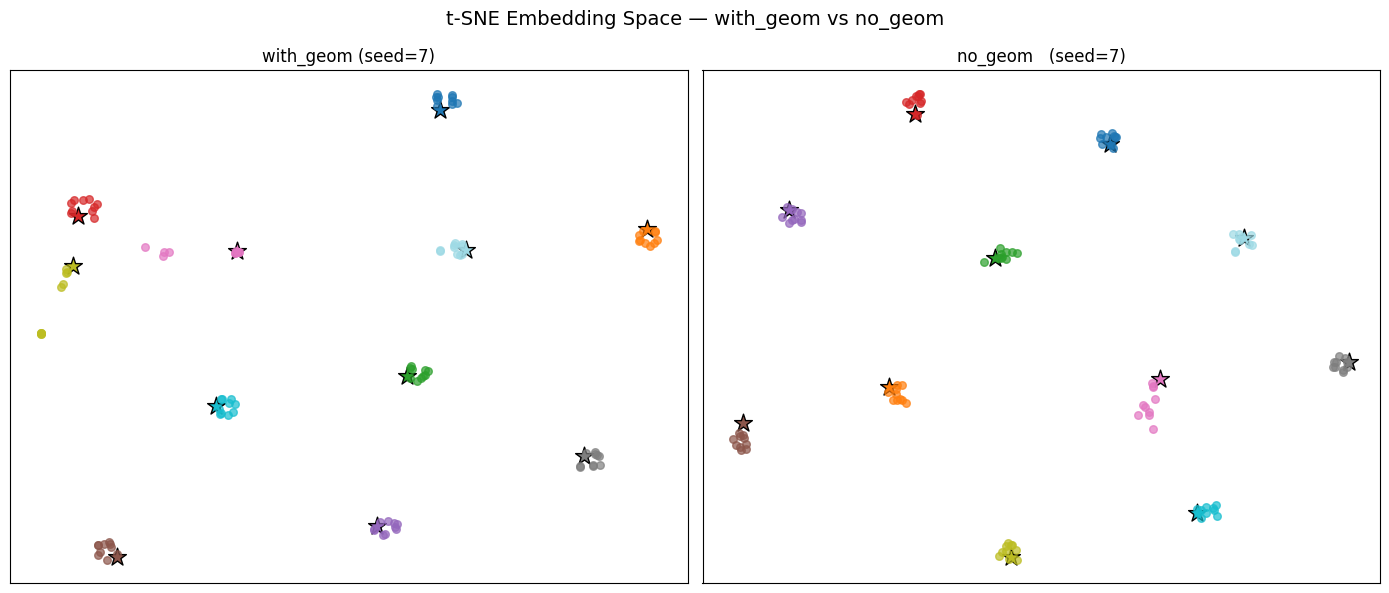

t-SNE side-by-side disimpan: /content/drive/MyDrive/3DCNN/eval_results/compare/20260516_225103/tsne_side_by_side.png


In [8]:
# ── t-SNE side-by-side (seed representatif) ─────────────────────────────────
from sklearn.manifold import TSNE

def tsne_panel(ax, npz, title: str, cmap):
    gallery_embs   = npz['gallery_embs']
    gallery_labels = npz['gallery_labels']
    probe_embs     = npz['probe_embs']
    probe_true     = npz['probe_true_labels']
    all_embs   = np.vstack([gallery_embs, probe_embs])
    all_labels = np.concatenate([gallery_labels, probe_true])
    uniq = sorted(set(all_labels.tolist()))
    label_to_int = {l: i for i, l in enumerate(uniq)}
    int_labels = np.array([label_to_int[l] for l in all_labels])
    n_gal = len(gallery_embs)
    perplexity = min(30, len(all_embs) - 1)
    coords = TSNE(n_components=2, random_state=42, perplexity=perplexity).fit_transform(all_embs)
    for i, lbl in enumerate(uniq):
        mask = int_labels == i
        gal_mask = mask.copy(); gal_mask[n_gal:] = False
        prb_mask = mask.copy(); prb_mask[:n_gal] = False
        if gal_mask.any():
            ax.scatter(coords[gal_mask, 0], coords[gal_mask, 1],
                       c=[cmap(i)], marker='*', s=180, edgecolor='black', linewidth=1)
        if prb_mask.any():
            ax.scatter(coords[prb_mask, 0], coords[prb_mask, 1],
                       c=[cmap(i)], s=30, alpha=0.7)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])


rep_seed = common_seeds[0]
npz_w = with_data['per_seed'][rep_seed].get('_npz')
npz_n = no_data['per_seed'][rep_seed].get('_npz')

if npz_w is not None and npz_n is not None:
    n_subj = len(set(npz_w['probe_true_labels'].tolist()) | set(npz_w['gallery_labels'].tolist()))
    cmap = plt.cm.get_cmap('tab20', max(n_subj, 4))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    tsne_panel(axes[0], npz_w, f'with_geom (seed={rep_seed})', cmap)
    tsne_panel(axes[1], npz_n, f'no_geom   (seed={rep_seed})', cmap)
    fig.suptitle('t-SNE Embedding Space — with_geom vs no_geom', fontsize=14)
    fig.tight_layout()
    tsne_path = COMPARE_DIR / 'tsne_side_by_side.png'
    fig.savefig(tsne_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f't-SNE side-by-side disimpan: {tsne_path}')
else:
    print('embeddings .npz tidak lengkap — t-SNE side-by-side dilewati.')

## 7. Verdict & Ekspor `comparison_report.md`

**Verdict TERBUKTI** memerlukan ketiga kondisi pada metrik primer (Rank-1):
1. mean(with_geom) > mean(no_geom)
2. paired test p < 0.05
3. bootstrap 95% CI (delta) tidak melingkupi 0

Jika hanya 1-2 kondisi terpenuhi → SEBAGIAN TERBUKTI. Jika tidak ada → TIDAK TERBUKTI.

In [9]:
def determine_verdict(stats: dict, key: str = 'rank1') -> tuple[str, list[str]]:
    """Tentukan verdict berdasarkan kondisi statistik untuk metrik primer."""
    paired = stats[key]['paired']
    boot   = stats[key]['bootstrap']

    cond_mean   = boot['mean'] > 0
    cond_pvalue = paired['pvalue'] < 0.05
    cond_ci     = boot['ci_low'] > 0  # CI bawah > 0 → with_geom signifikan lebih baik

    n_passed = sum([cond_mean, cond_pvalue, cond_ci])
    reasons = [
        f"mean(with_geom) > mean(no_geom): {'✓' if cond_mean else '✗'}  "
        f"(delta={boot['mean']:+.4f})",
        f"paired test p < 0.05: {'✓' if cond_pvalue else '✗'}  "
        f"({paired['test']} p={paired['pvalue']:.4f})",
        f"bootstrap CI 95% tidak melingkupi 0: {'✓' if cond_ci else '✗'}  "
        f"([{boot['ci_low']:+.4f}, {boot['ci_high']:+.4f}])",
    ]

    if n_passed == 3:
        verdict = 'TERBUKTI'
    elif n_passed >= 1 and cond_mean:
        verdict = 'SEBAGIAN TERBUKTI'
    else:
        verdict = 'TIDAK TERBUKTI'
    return verdict, reasons


verdict, reasons = determine_verdict(stats_results, key='rank1')
print('=' * 64)
print(f'VERDICT (berdasarkan Rank-1) : {verdict}')
print('=' * 64)
for r in reasons:
    print(f'  - {r}')

# ── Tulis comparison_report.md ───────────────────────────────────────────────
def fmt(v, prec=4):
    return f'{v:.{prec}f}'

report_lines = []
report_lines.append('# Laporan Komparasi: Dengan vs Tanpa Fitur Geometri')
report_lines.append('')
report_lines.append(f'_Generated: {COMPARE_TIMESTAMP}_')
report_lines.append('')
report_lines.append('## Pertanyaan Riset')
report_lines.append('Apakah penambahan 14 fitur geometri ke GeoAtt-PointNet++ memberikan dampak signifikan pada akurasi identifikasi telapak tangan (1:N)?')
report_lines.append('')
report_lines.append('## Konfigurasi Eksperimen')
report_lines.append(f'- with_geom run : `{Path(with_data["run_dir"]).name}`')
report_lines.append(f'- no_geom run   : `{Path(no_data["run_dir"]).name}`')
report_lines.append(f'- Test fingerprint (identik) : `{fp_with}`')
report_lines.append(f'- Seed yang dipasangkan     : `{common_seeds}` (n={len(common_seeds)})')
report_lines.append('')

report_lines.append('## Headline — Identifikasi 1:N (Mean ± Std)')
report_lines.append('')
report_lines.append('| Metrik | with_geom | no_geom | Δ | Improvement | Geom lebih baik? |')
report_lines.append('|---|---|---|---|---|---|')
for _, row in df_primary.iterrows():
    report_lines.append(
        f"| {row['Metrik']} "
        f"| {fmt(row['with_geom_mean'])} ± {fmt(row['with_geom_std'])} "
        f"| {fmt(row['no_geom_mean'])} ± {fmt(row['no_geom_std'])} "
        f"| {row['delta']:+.4f} "
        f"| {row['improvement_%']:+.1f}% "
        f"| {row['geom_better']} |"
    )
report_lines.append('')

report_lines.append('## Statistik Inferensial (Rank-1)')
paired = stats_results['rank1']['paired']
boot   = stats_results['rank1']['bootstrap']
report_lines.append('')
report_lines.append(f'- **Paired {paired["test"]}** : statistic = {paired["statistic"]:.4f}, p = {paired["pvalue"]:.4f}, n = {paired["n"]}')
report_lines.append(f'- **Bootstrap CI 95%** (delta = with − no) : [{boot["ci_low"]:+.4f}, {boot["ci_high"]:+.4f}]  (n_bootstrap={boot["n_bootstrap"]})')
mcn = stats_results.get('mcnemar_rank1')
if mcn:
    report_lines.append(f'- **McNemar test** (per-probe Rank-1, gabung seed n={mcn["n"]}) : χ² = {mcn["statistic"]:.4f}, p = {mcn["pvalue"]:.4f}, b = {mcn["b"]} (no_geom benar saja), c = {mcn["c"]} (with_geom benar saja)')
report_lines.append('')

report_lines.append('## Verdict')
report_lines.append('')
report_lines.append(f'**{verdict}**')
report_lines.append('')
report_lines.append('Kondisi yang dievaluasi:')
for r in reasons:
    report_lines.append(f'- {r}')
report_lines.append('')

report_lines.append('## Verifikasi 1:1 (Sekunder)')
report_lines.append('')
report_lines.append('| Metrik | with_geom | no_geom | Δ | Improvement | Geom lebih baik? |')
report_lines.append('|---|---|---|---|---|---|')
for _, row in df_secondary.iterrows():
    report_lines.append(
        f"| {row['Metrik']} "
        f"| {fmt(row['with_geom_mean'])} ± {fmt(row['with_geom_std'])} "
        f"| {fmt(row['no_geom_mean'])} ± {fmt(row['no_geom_std'])} "
        f"| {row['delta']:+.4f} "
        f"| {row['improvement_%']:+.1f}% "
        f"| {row['geom_better']} |"
    )
report_lines.append('')

report_lines.append('## Visualisasi')
report_lines.append('')
report_lines.append('![CMC Overlay](cmc_overlay.png)')
report_lines.append('')
report_lines.append('![Bar Chart Rank-N](bar_chart_rank.png)')
report_lines.append('')
report_lines.append('![t-SNE Side-by-Side](tsne_side_by_side.png)')
report_lines.append('')

report_lines.append('## Catatan Metodologis')
report_lines.append('')
report_lines.append('- Tugas tesis adalah **identifikasi 1:N** → metrik utama Rank-1, Rank-5, Rank-10, mAP, CMC.')
report_lines.append('- Metrik verifikasi 1:1 (EER, AUC, TAR@FAR) ditampilkan sebagai pelengkap.')
report_lines.append('- `test_fingerprint` identik antar varian dipastikan secara otomatis sebelum komparasi.')
report_lines.append('- Paired test memakai Wilcoxon untuk n<10 seed (lebih robust pada sampel kecil).')
report_lines.append('- Bootstrap CI memakai resampling paired (n_bootstrap=2000) untuk delta mean.')

report_md = '\n'.join(report_lines)
report_path = COMPARE_DIR / 'comparison_report.md'
with open(report_path, 'w') as f:
    f.write(report_md)

print(f'\ncomparison_report.md disimpan: {report_path}')
print('--- preview ---')
print(report_md[:1500])

VERDICT (berdasarkan Rank-1) : TIDAK TERBUKTI
  - mean(with_geom) > mean(no_geom): ✗  (delta=-0.0400)
  - paired test p < 0.05: ✗  (wilcoxon p=0.0625)
  - bootstrap CI 95% tidak melingkupi 0: ✗  ([-0.0527, -0.0309])

comparison_report.md disimpan: /content/drive/MyDrive/3DCNN/eval_results/compare/20260516_225103/comparison_report.md
--- preview ---
# Laporan Komparasi: Dengan vs Tanpa Fitur Geometri

_Generated: 20260516_225103_

## Pertanyaan Riset
Apakah penambahan 14 fitur geometri ke GeoAtt-PointNet++ memberikan dampak signifikan pada akurasi identifikasi telapak tangan (1:N)?

## Konfigurasi Eksperimen
- with_geom run : `20260516_223830`
- no_geom run   : `20260516_223800`
- Test fingerprint (identik) : `34b90906c80ab1eb`
- Seed yang dipasangkan     : `[7, 42, 123, 2026, 31337]` (n=5)

## Headline — Identifikasi 1:N (Mean ± Std)

| Metrik | with_geom | no_geom | Δ | Improvement | Geom lebih baik? |
|---|---|---|---|---|---|
| rank1 | 0.9582 ± 0.0159 | 0.9982 ± 0.0036 | -0.0400 | -

In [10]:
# ── Ekspor comparison_summary.json (mesin-bisa-baca) ────────────────────────
def stat_to_json(stat: dict) -> dict:
    return {k: (float(v) if isinstance(v, (np.floating, np.integer)) else v)
            for k, v in stat.items()}


summary = {
    'compare_timestamp': COMPARE_TIMESTAMP,
    'with_geom_run':     Path(with_data['run_dir']).name,
    'no_geom_run':       Path(no_data['run_dir']).name,
    'test_fingerprint':  fp_with,
    'seeds_paired':      common_seeds,
    'verdict':           verdict,
    'verdict_reasons':   reasons,
    'metrics': {
        'primary':   df_primary.to_dict(orient='records'),
        'secondary': df_secondary.to_dict(orient='records'),
    },
    'inferential': {
        key: {
            'paired':    stat_to_json(stats_results[key]['paired']),
            'bootstrap': stat_to_json(stats_results[key]['bootstrap']),
        } for key in PRIMARY_KEYS
    },
}
if stats_results.get('mcnemar_rank1'):
    summary['inferential']['mcnemar_rank1'] = stat_to_json(stats_results['mcnemar_rank1'])

# Convert numpy types in nested dicts
def _clean(o):
    if isinstance(o, dict):
        return {k: _clean(v) for k, v in o.items()}
    if isinstance(o, list):
        return [_clean(v) for v in o]
    if isinstance(o, (np.floating, np.integer)):
        return float(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    return o

summary = _clean(summary)
summary_path = COMPARE_DIR / 'comparison_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f'comparison_summary.json disimpan: {summary_path}')
print()
print('=' * 64)
print(f'KOMPARASI SELESAI · Verdict: {verdict}')
print('=' * 64)
print(f'Output folder: {COMPARE_DIR}')
print('File yang dihasilkan:')
for f in sorted(COMPARE_DIR.iterdir()):
    if f.is_file():
        size_kb = f.stat().st_size / 1024
        print(f'  {f.name:<35} {size_kb:>7.1f} KB')

comparison_summary.json disimpan: /content/drive/MyDrive/3DCNN/eval_results/compare/20260516_225103/comparison_summary.json

KOMPARASI SELESAI · Verdict: TIDAK TERBUKTI
Output folder: /content/drive/MyDrive/3DCNN/eval_results/compare/20260516_225103
File yang dihasilkan:
  bar_chart_rank.png                     46.7 KB
  cmc_overlay.png                        57.3 KB
  comparison_report.md                    2.5 KB
  comparison_summary.json                 4.8 KB
  tsne_side_by_side.png                 102.3 KB
